## Intensity
In this chapter, we will work with a hand radiograph from a 2017 Radiological Society of North America competition. X-ray absorption is highest in dense tissue such as bone, so the resulting intensities should be high. Consequently, images like this can be used to predict "bone age" in children.

To start, let's load the image and check its intensity range.

The image datatype determines the range of possible intensities: e.g., 8-bit unsigned integers (uint8) can take values in the range of 0 to 255. A colorbar can be helpful for connecting these values to the visualized image.

All exercises in this chapter have the following imports:

import imageio
import numpy as np
import matplotlib.pyplot as plt

- Load the image "hand-xray.jpg" using imageio.
- Print the image's data type (dtype), minimum (min()) and maximum intensity (max()).
- Plot the image using plt.imshow(). Explicitly set the colormap's minimum (0) and maximum (255) values using the vmin and vmax arguments.
- Add a colorbar using plt.colorbar(), then render the plot using the custom function format_and_render_plot(). This has been done for you.

In [ ]:
# Load the hand radiograph
im = imageio.imread('hand-xray.jpg')
print('Data type:', im.dtype)
print('Min. value:', im.min())
print('Max value:', im.max())

# Plot the grayscale image
plt.imshow(im, vmin=0, vmax=255)
plt.colorbar()
format_and_render_plot()

Data type: uint8
Min. value: 1
Max value: 230

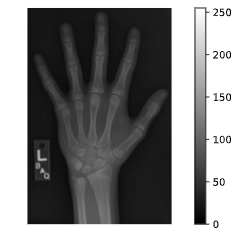

## Histograms
Histograms display the distribution of values in your image by binning each element by its intensity then measuring the size of each bin.

The area under a histogram is called the cumulative distribution function. It measures the frequency with which a given range of pixel intensities occurs.

For this exercise, describe the intensity distribution in im by calculating the histogram and cumulative distribution function and displaying them together.

- Import scipy.ndimage as ndi.
- Generate a 256-bin histogram of im which covers the full range of np.uint8 values.
- Calculate the cumulative distribution function for im. First, find the cumulative sum of hist, then divide by the total number of pixels in hist.
- Plot hist and cdf on separate subplots. This has been done for you.

In [ ]:
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi 

# Create a histogram, binned at each possible value
hist = ndi.histogram(im, min=0, max=255, bins=256)

# Create a cumulative distribution function
cdf = hist.cumsum() / hist.sum()

# Plot the histogram and CDF
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(hist, label='Histogram')
axes[1].plot(cdf, label='CDF')
format_and_render_plot()

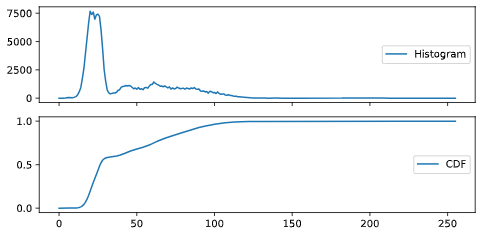

Great work. You can see the data is clumped into a few separate distributions, consisting of background noise, skin, bone, and artifacts. Sometimes we can separate these well with global thresholds (foreground/background); other times the distributions overlap quite a bit (skin/bone).